# 03 – Regression

**Bachelorarbeit – Mohamed Mohamady · Universität Paderborn · 2026**
*Panel-Regression M1–M10, VIF, Interaktion/Marginaleffekte und alle Tabellen.*

Ausgaben werden in `03_Output/final_run/` gespeichert. Wiederkehrende Bausteine
(Cluster-Definition, Farben, Tabellen-Renderer) liegen in `utils.py`.


## 1. Bibliotheken und Pfade

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from linearmodels.panel import PanelOLS
import warnings
warnings.filterwarnings("ignore")

# Shared cluster definition, colours and table helper (see utils.py)
sys.path.insert(0, r"C:\Users\LEGION\Desktop\Bachelorarbeit\02_Code\final_notebooks")
from utils import make_clusters, save_table, GREEN, ORANGE, CLUSTER_VARS

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 11

CLEAN_DATA = Path(r"C:\Users\LEGION\Desktop\Bachelorarbeit\03_Output\final_run\master_panel_clean.xlsx")
OUTPUT_DIR = Path(r"C:\Users\LEGION\Desktop\Bachelorarbeit\03_Output\final_run")

## Hilfsfunktionen (regressionsspezifisch)

In [2]:
def add_derived(panel):
    """Add log(secure servers), mean-centred predictors and the two interaction terms."""
    panel = panel.copy()
    panel["Secure_Servers_Log"] = np.log(panel["Secure_Servers"])
    for column in ["Internet Use", "Internet Purchases", "HighTech_Exports", "R&D expenditure", "Tertiary_Education"]:
        panel[column + "_c"] = panel[column] - panel[column].mean()
    panel["Use_x_Tert"] = panel["Internet Use_c"] * panel["Tertiary_Education_c"]
    panel["Purch_x_Tert"] = panel["Internet Purchases_c"] * panel["Tertiary_Education_c"]
    return panel


def two_way_fe(panel, predictors):
    """Two-way (country + year) fixed-effects model with country-clustered SE."""
    return PanelOLS(panel["GDP Per Capita PPS"], sm.add_constant(panel[predictors]),
                    entity_effects=True, time_effects=True).fit(cov_type="clustered", cluster_entity=True)


def stars(p_value):
    """Significance stars for a p-value."""
    if p_value < 0.01:
        return "***"
    if p_value < 0.05:
        return "**"
    if p_value < 0.1:
        return "*"
    return ""


def marginal_effect_plot(model, focal, interaction, focal_label, panel, out_path, title):
    """Plot the marginal effect of `focal` on GDP across tertiary education (Delta method)."""
    beta_focal = model.params[focal]
    beta_interaction = model.params[interaction]
    cov = model.cov
    var_focal = cov.loc[focal, focal]
    var_interaction = cov.loc[interaction, interaction]
    cov_focal_interaction = cov.loc[focal, interaction]

    tertiary_mean = panel["Tertiary_Education"].mean()
    centred = np.linspace(panel["Tertiary_Education_c"].min(), panel["Tertiary_Education_c"].max(), 200)
    effect = beta_focal + beta_interaction * centred
    std_error = np.sqrt(var_focal + centred**2 * var_interaction + 2 * centred * cov_focal_interaction)
    tertiary_axis = centred + tertiary_mean

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.fill_between(tertiary_axis, effect - 1.96 * std_error, effect + 1.96 * std_error,
                    alpha=0.2, color="#2E86AB", label="95% Confidence Band")
    ax.plot(tertiary_axis, effect, color="#2E86AB", lw=2.5, label=f"Marginal association of {focal_label}")
    ax.axhline(0, color="black", ls="--", lw=1.2, alpha=0.7, label="Association = 0")
    for marker in [50, tertiary_mean, 85]:
        ax.axvline(marker, color="gray", ls=":", lw=0.8, alpha=0.5)
    ax.set_xlabel("Education (ISCED 3-8)")
    ax.set_ylabel("Estimated marginal association with GDP per capita (PPS)")
    ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

## 2. Daten laden, ableiten und Panelstruktur

In [3]:
# Cleaned panel from notebook 01, plus the derived columns the models need.
panel = add_derived(pd.read_excel(CLEAN_DATA).sort_values(["Country", "Year"]).reset_index(drop=True))

# Cluster labels are only used to colour the R&D scatter later on.
panel, country_means, advanced, NAMES, COLORS = make_clusters(panel)

# linearmodels needs a (entity, time) MultiIndex.
panel_indexed = panel.set_index(["Country", "Year"])
print("Panel:", panel.shape)

Panel: (216, 22)


## 3. Tabelle 4 – Übersicht der Regressionsmodelle

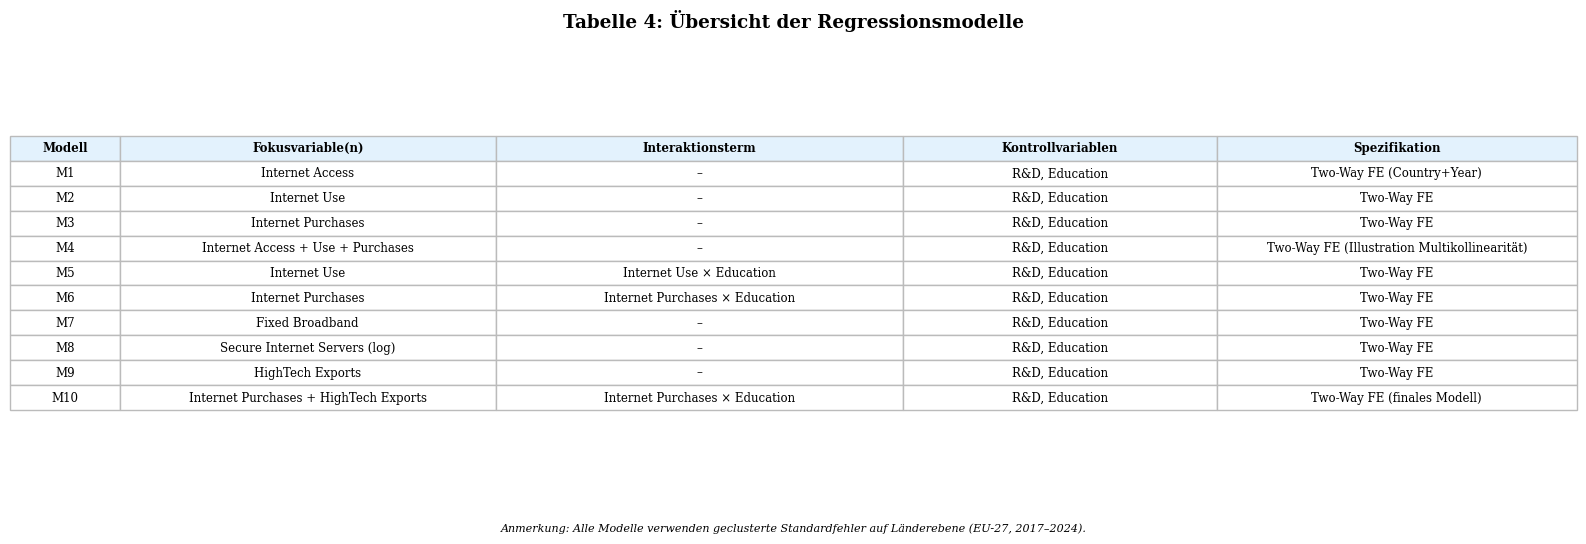

In [4]:
model_overview = [
    ["M1", "Internet Access", "–", "R&D, Education", "Two-Way FE (Country+Year)"],
    ["M2", "Internet Use", "–", "R&D, Education", "Two-Way FE"],
    ["M3", "Internet Purchases", "–", "R&D, Education", "Two-Way FE"],
    ["M4", "Internet Access + Use + Purchases", "–", "R&D, Education", "Two-Way FE (Illustration Multikollinearität)"],
    ["M5", "Internet Use", "Internet Use × Education", "R&D, Education", "Two-Way FE"],
    ["M6", "Internet Purchases", "Internet Purchases × Education", "R&D, Education", "Two-Way FE"],
    ["M7", "Fixed Broadband", "–", "R&D, Education", "Two-Way FE"],
    ["M8", "Secure Internet Servers (log)", "–", "R&D, Education", "Two-Way FE"],
    ["M9", "HighTech Exports", "–", "R&D, Education", "Two-Way FE"],
    ["M10", "Internet Purchases + HighTech Exports", "Internet Purchases × Education", "R&D, Education", "Two-Way FE (finales Modell)"],
]
save_table(model_overview, ["Modell", "Fokusvariable(n)", "Interaktionsterm", "Kontrollvariablen", "Spezifikation"],
           OUTPUT_DIR / "table4_model_overview.png", "Tabelle 4: Übersicht der Regressionsmodelle",
           col_widths=[0.07, 0.24, 0.26, 0.20, 0.23], fontsize=8.5, figsize=(16, 5.5),
           note="Anmerkung: Alle Modelle verwenden geclusterte Standardfehler auf Länderebene (EU-27, 2017–2024).")

## 4. Schätzung der Modelle M1–M10

In [5]:
models = {}
models["M1"] = two_way_fe(panel_indexed, ["Internet Access", "R&D expenditure", "Tertiary_Education"])
models["M2"] = two_way_fe(panel_indexed, ["Internet Use", "R&D expenditure", "Tertiary_Education"])
models["M3"] = two_way_fe(panel_indexed, ["Internet Purchases", "R&D expenditure", "Tertiary_Education"])
models["M4"] = two_way_fe(panel_indexed, ["Internet Access", "Internet Use", "Internet Purchases", "R&D expenditure", "Tertiary_Education"])
models["M5"] = two_way_fe(panel_indexed, ["Internet Use_c", "Tertiary_Education_c", "Use_x_Tert", "R&D expenditure_c"])
models["M6"] = two_way_fe(panel_indexed, ["Internet Purchases_c", "Tertiary_Education_c", "Purch_x_Tert", "R&D expenditure_c"])
models["M7"] = two_way_fe(panel_indexed, ["Fixed_Broadband", "R&D expenditure", "Tertiary_Education"])
models["M8"] = two_way_fe(panel_indexed, ["Secure_Servers_Log", "R&D expenditure", "Tertiary_Education"])
models["M9"] = two_way_fe(panel_indexed, ["HighTech_Exports", "R&D expenditure", "Tertiary_Education"])
models["M10"] = two_way_fe(panel_indexed, ["Internet Purchases_c", "HighTech_Exports_c", "R&D expenditure_c", "Tertiary_Education_c", "Purch_x_Tert"])

for name in ["M1", "M2", "M3", "M4", "M5", "M6", "M7", "M8", "M9", "M10"]:
    print(f"{name:4s} | Within R² = {models[name].rsquared:.4f} | N = {int(models[name].nobs)}")

M1   | Within R² = 0.3517 | N = 216
M2   | Within R² = 0.3730 | N = 216
M3   | Within R² = 0.4043 | N = 216
M4   | Within R² = 0.4116 | N = 216
M5   | Within R² = 0.4711 | N = 216
M6   | Within R² = 0.4788 | N = 216
M7   | Within R² = 0.3568 | N = 216
M8   | Within R² = 0.3462 | N = 216
M9   | Within R² = 0.4192 | N = 216
M10  | Within R² = 0.5082 | N = 216


## 5. Tabelle 7 – Vollständige Regressionsergebnisse

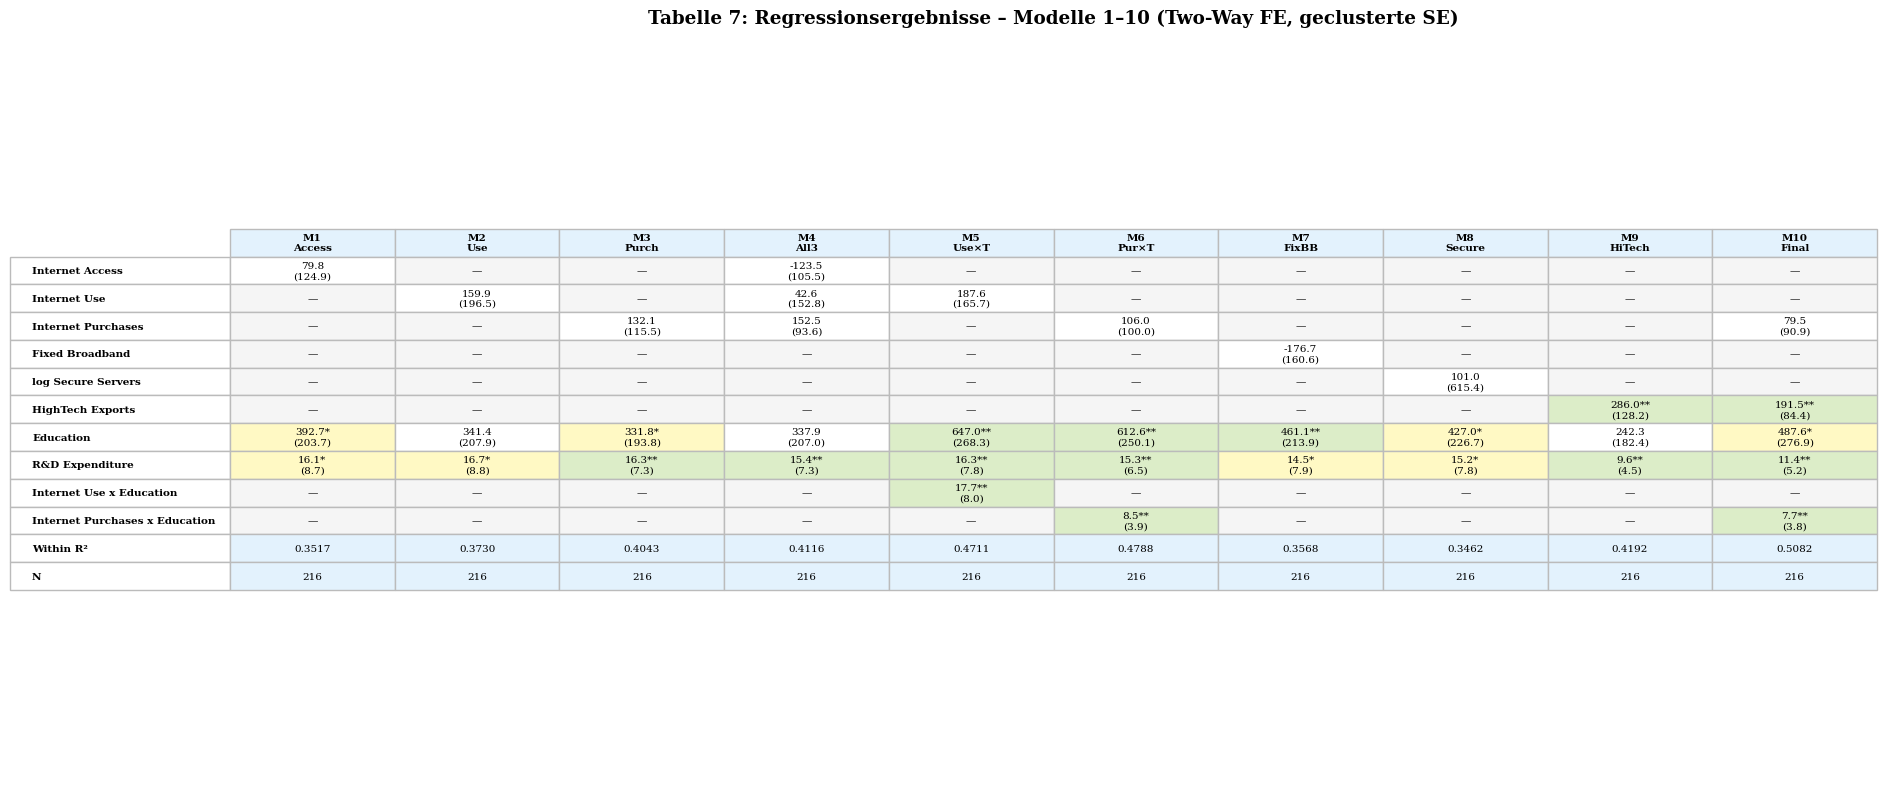

In [6]:
# Each display row maps to one or more possible parameter names (centred or not).
display_rows = [
    ("Internet Access", ["Internet Access"]),
    ("Internet Use", ["Internet Use", "Internet Use_c"]),
    ("Internet Purchases", ["Internet Purchases", "Internet Purchases_c"]),
    ("Fixed Broadband", ["Fixed_Broadband"]),
    ("log Secure Servers", ["Secure_Servers_Log"]),
    ("HighTech Exports", ["HighTech_Exports", "HighTech_Exports_c"]),
    ("Education", ["Tertiary_Education", "Tertiary_Education_c"]),
    ("R&D Expenditure", ["R&D expenditure", "R&D expenditure_c"]),
    ("Internet Use x Education", ["Use_x_Tert"]),
    ("Internet Purchases x Education", ["Purch_x_Tert"]),
]
model_order = ["M1", "M2", "M3", "M4", "M5", "M6", "M7", "M8", "M9", "M10"]
column_labels = ["M1\nAccess", "M2\nUse", "M3\nPurch", "M4\nAll3", "M5\nUse×T",
                 "M6\nPur×T", "M7\nFixBB", "M8\nSecure", "M9\nHiTech", "M10\nFinal"]


def significance_color(p_value):
    if p_value < 0.01:
        return "#C8E6C9"
    if p_value < 0.05:
        return "#DCEDC8"
    if p_value < 0.1:
        return "#FFF9C4"
    return "white"


cell_text, cell_colors = [], []
for label, candidate_names in display_rows:
    text_row, color_row = [], []
    for name in model_order:
        model = models[name]
        match = next((c for c in candidate_names if c in model.params.index), None)
        if match is not None:
            coef, se, p = model.params[match], model.std_errors[match], model.pvalues[match]
            text_row.append(f"{coef:.1f}{stars(p)}\n({se:.1f})")
            color_row.append(significance_color(p))
        else:
            text_row.append("—")
            color_row.append("#F5F5F5")
    cell_text.append(text_row)
    cell_colors.append(color_row)

cell_text.append([f"{models[name].rsquared:.4f}" for name in model_order])
cell_colors.append(["#E3F2FD"] * 10)
cell_text.append(["216"] * 10)
cell_colors.append(["#E3F2FD"] * 10)

save_table(cell_text, column_labels, OUTPUT_DIR / "table7_regression_results.png",
           "Tabelle 7: Regressionsergebnisse – Modelle 1–10 (Two-Way FE, geclusterte SE)",
           row_labels=[label for label, _ in display_rows] + ["Within R²", "N"],
           cell_colors=cell_colors, figsize=(19, 8), fontsize=7.5)

## 6. Tabelle 5 – Multikollinearitätsprüfung (VIF)

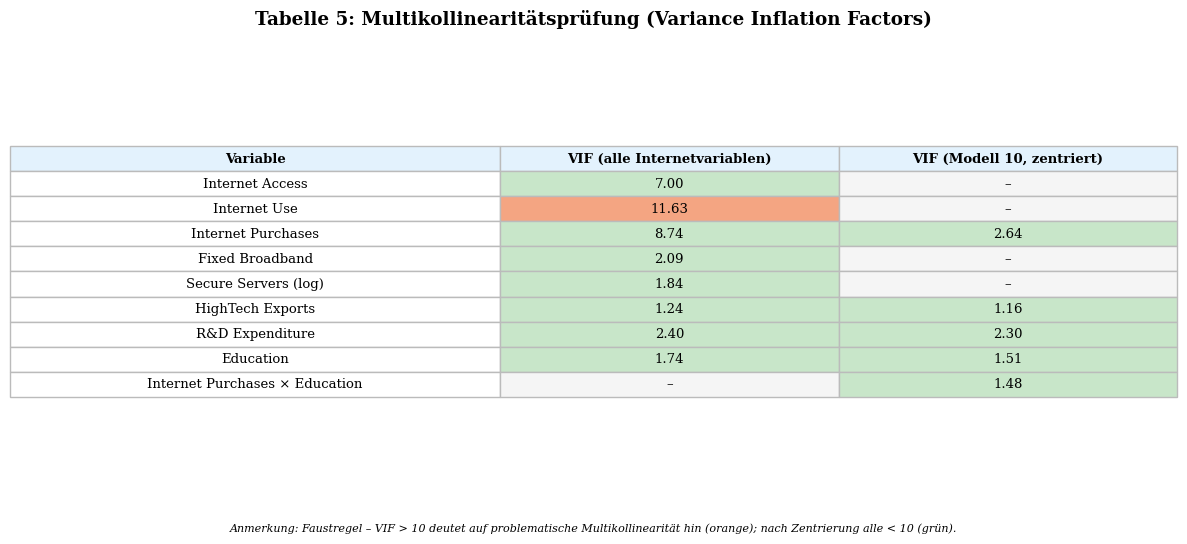

In [7]:
# The VIFs are computed on the pooled (untransformed) regressors -- standard
# practice; the within (fixed-effects) transformation is not applied here.
def vif_values(columns):
    design = sm.add_constant(panel[columns])
    return {column: variance_inflation_factor(design.values, i + 1) for i, column in enumerate(columns)}


naive_columns = ["Internet Access", "Internet Use", "Internet Purchases", "Fixed_Broadband",
                 "Secure_Servers_Log", "HighTech_Exports", "R&D expenditure", "Tertiary_Education"]
model10_columns = ["Internet Purchases_c", "HighTech_Exports_c", "R&D expenditure_c",
                   "Tertiary_Education_c", "Purch_x_Tert"]
vif_naive = vif_values(naive_columns)
vif_model10 = vif_values(model10_columns)

# (display label, name in the naive spec, name in the Model-10 spec)
vif_rows_spec = [
    ("Internet Access", "Internet Access", None),
    ("Internet Use", "Internet Use", None),
    ("Internet Purchases", "Internet Purchases", "Internet Purchases_c"),
    ("Fixed Broadband", "Fixed_Broadband", None),
    ("Secure Servers (log)", "Secure_Servers_Log", None),
    ("HighTech Exports", "HighTech_Exports", "HighTech_Exports_c"),
    ("R&D Expenditure", "R&D expenditure", "R&D expenditure_c"),
    ("Education", "Tertiary_Education", "Tertiary_Education_c"),
    ("Internet Purchases × Education", None, "Purch_x_Tert"),
]


def vif_color(value):
    if value is None:
        return "#F5F5F5"
    return "#F4A582" if value > 10 else "#C8E6C9"


vif_text, vif_colors = [], []
for label, naive_name, model10_name in vif_rows_spec:
    naive_value = vif_naive.get(naive_name) if naive_name else None
    model10_value = vif_model10.get(model10_name) if model10_name else None
    vif_text.append([label,
                     f"{naive_value:.2f}" if naive_value is not None else "–",
                     f"{model10_value:.2f}" if model10_value is not None else "–"])
    vif_colors.append(["white", vif_color(naive_value), vif_color(model10_value)])

save_table(vif_text, ["Variable", "VIF (alle Internetvariablen)", "VIF (Modell 10, zentriert)"],
           OUTPUT_DIR / "table5_vif_results.png",
           "Tabelle 5: Multikollinearitätsprüfung (Variance Inflation Factors)",
           cell_colors=vif_colors, col_widths=[0.42, 0.29, 0.29], fontsize=9.5, figsize=(12, 5.5),
           note="Anmerkung: Faustregel – VIF > 10 deutet auf problematische Multikollinearität hin (orange); nach Zentrierung alle < 10 (grün).")

## 7. Regressions-Abbildungen: Koeffizienten, R², R&D-Scatter

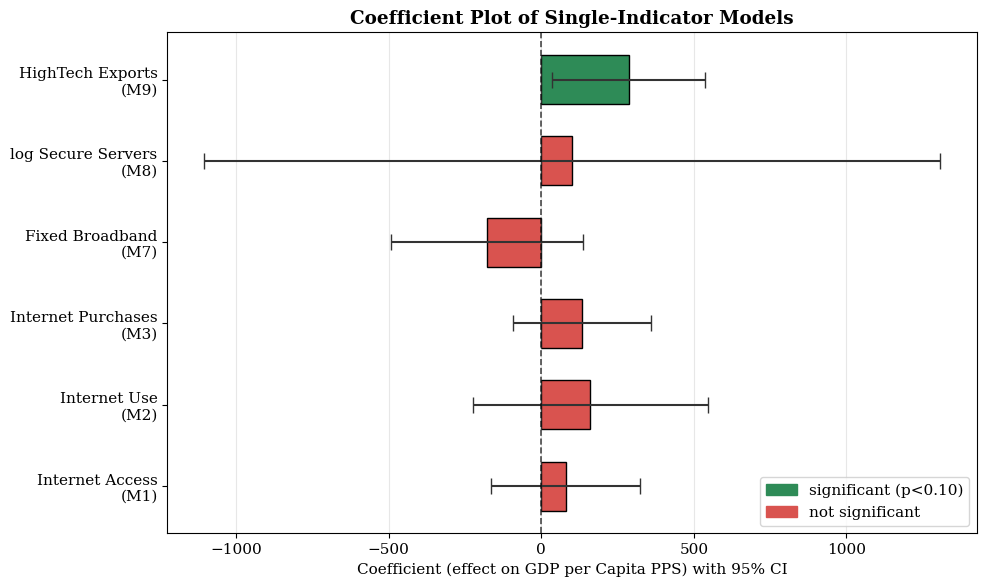

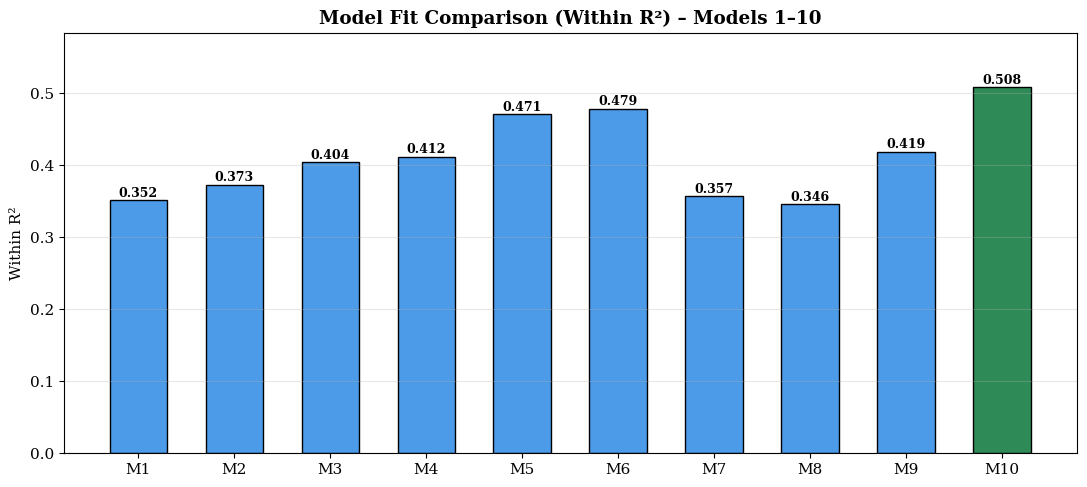

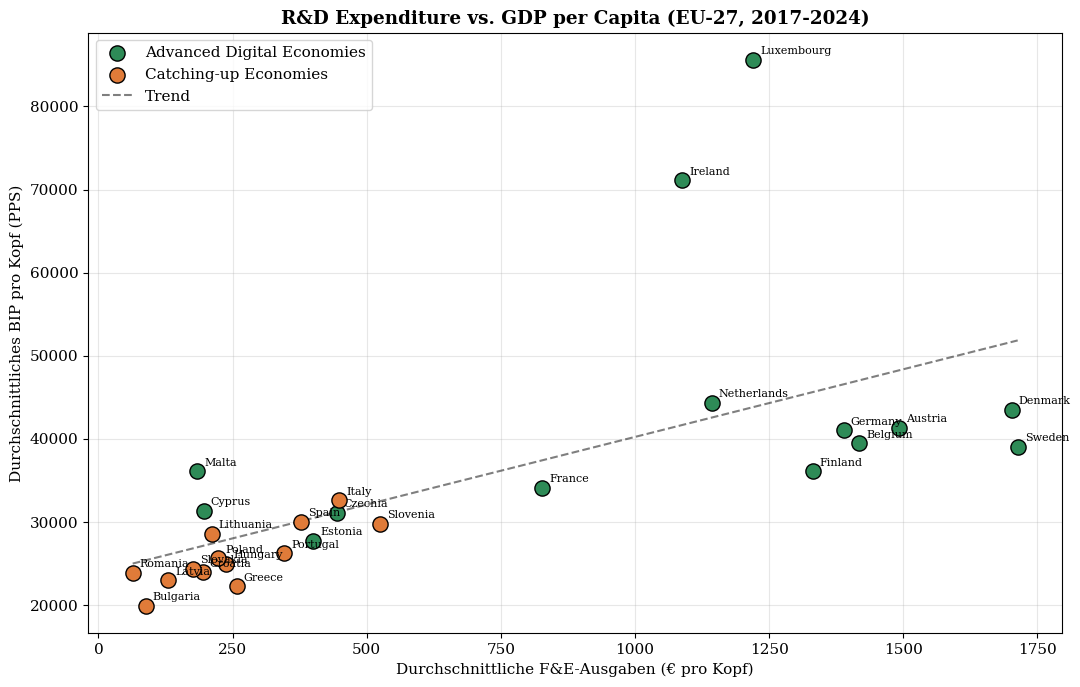

In [8]:
# Coefficient plot for the single-indicator models, with 95% CI.
single_indicator = [
    ("M1", "Internet Access", "Internet Access"),
    ("M2", "Internet Use", "Internet Use"),
    ("M3", "Internet Purchases", "Internet Purchases"),
    ("M7", "Fixed_Broadband", "Fixed Broadband"),
    ("M8", "Secure_Servers_Log", "log Secure Servers"),
    ("M9", "HighTech_Exports", "HighTech Exports"),
]
labels = [f"{label}\n({name})" for name, var, label in single_indicator]
coefs = [models[name].params[var] for name, var, label in single_indicator]
errors = [1.96 * models[name].std_errors[var] for name, var, label in single_indicator]
bar_colors = ["#2E8B57" if models[name].pvalues[var] < 0.1 else "#d9534f" for name, var, label in single_indicator]

fig, ax = plt.subplots(figsize=(10, 6))
positions = np.arange(len(labels))
ax.barh(positions, coefs, xerr=errors, color=bar_colors, edgecolor="black",
        error_kw=dict(ecolor="#333", capsize=6), height=0.6)
ax.axvline(0, color="black", ls="--", lw=1.2, alpha=0.7)
ax.set_yticks(positions)
ax.set_yticklabels(labels)
ax.set_xlabel("Coefficient (effect on GDP per Capita PPS) with 95% CI")
ax.set_title("Coefficient Plot of Single-Indicator Models", fontweight="bold")
ax.legend(handles=[mpatches.Patch(color="#2E8B57", label="significant (p<0.10)"),
                   mpatches.Patch(color="#d9534f", label="not significant")], loc="lower right")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "regression_coefficient_plot.png", dpi=300, bbox_inches="tight")
plt.show()

# Within-R2 comparison across all ten models.
r_squared = [models[name].rsquared for name in model_order]
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(model_order, r_squared, color=["#4C9BE8"] * 9 + ["#2E8B57"], edgecolor="black", width=0.6)
for bar, value in zip(bars, r_squared):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005, f"{value:.3f}",
            ha="center", fontsize=9, fontweight="bold")
ax.set_ylabel("Within R²")
ax.set_title("Model Fit Comparison (Within R²) – Models 1–10", fontweight="bold")
ax.set_ylim(0, max(r_squared) * 1.15)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "regression_r2_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# R&D vs GDP scatter, coloured by cluster (real cluster names, R&D in € pro Kopf).
country_summary = panel.groupby("Country").agg(
    GDP=("GDP Per Capita PPS", "mean"),
    RD=("R&D expenditure", "mean"),
    Cluster=("Cluster", "first")).reset_index()
fig, ax = plt.subplots(figsize=(11, 7))
for cluster in [advanced, 1 - advanced]:
    subset = country_summary[country_summary["Cluster"] == cluster]
    ax.scatter(subset["RD"], subset["GDP"], s=120, edgecolor="black",
               color=COLORS[cluster], label=NAMES[cluster], zorder=3)
    for _, row in subset.iterrows():
        ax.annotate(row["Country"], (row["RD"], row["GDP"]), xytext=(5, 4),
                    textcoords="offset points", fontsize=8)
slope, intercept = np.polyfit(country_summary["RD"], country_summary["GDP"], 1)
x_line = np.linspace(country_summary["RD"].min(), country_summary["RD"].max(), 100)
ax.plot(x_line, slope * x_line + intercept, "k--", lw=1.5, alpha=0.5, label="Trend")
ax.set_xlabel("Durchschnittliche F&E-Ausgaben (€ pro Kopf)")
ax.set_ylabel("Durchschnittliches BIP pro Kopf (PPS)")
ax.set_title("R&D Expenditure vs. GDP per Capita (EU-27, 2017-2024)", fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "regression_rd_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Interaktionsanalyse – Marginaleffekte (M5, M3a, M10)

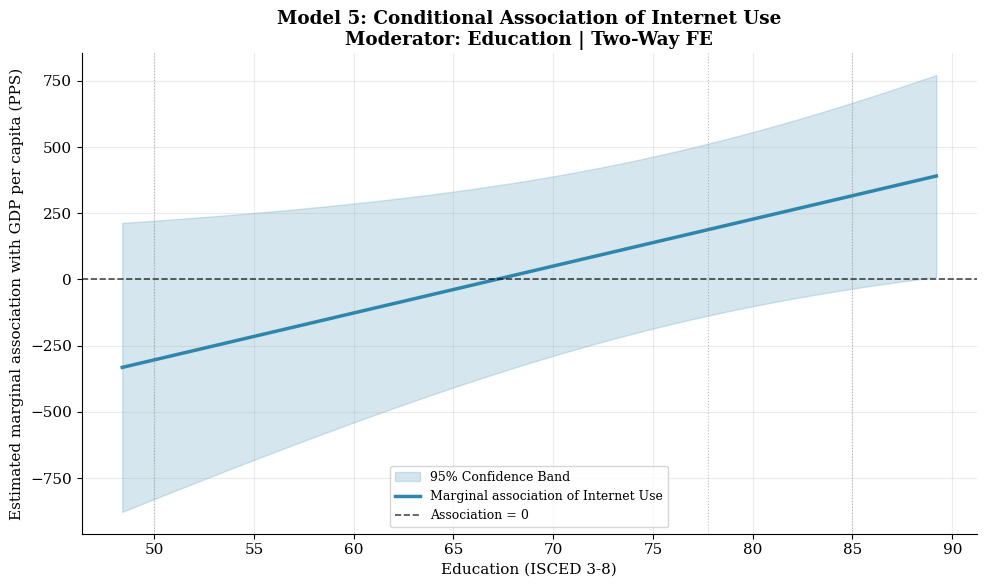

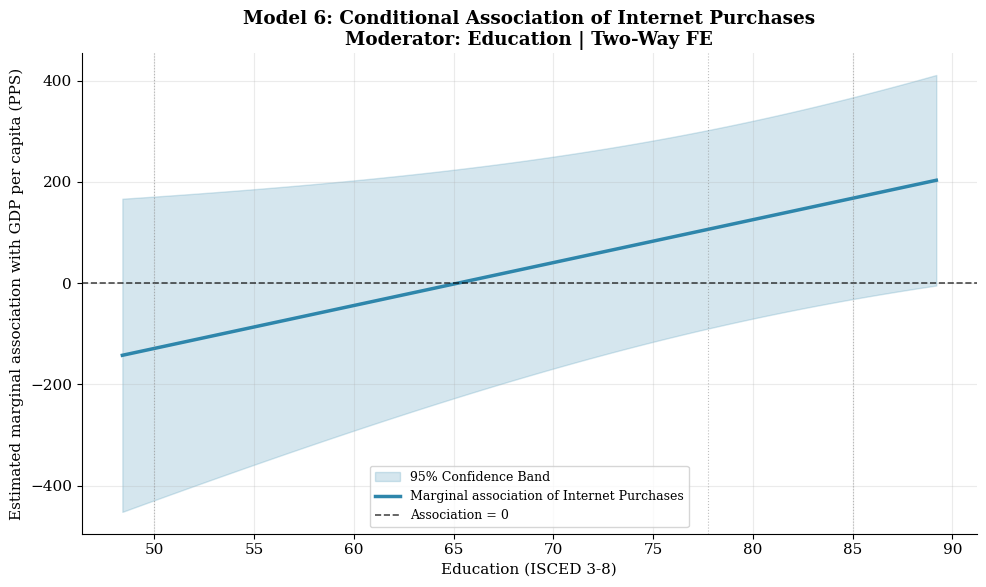

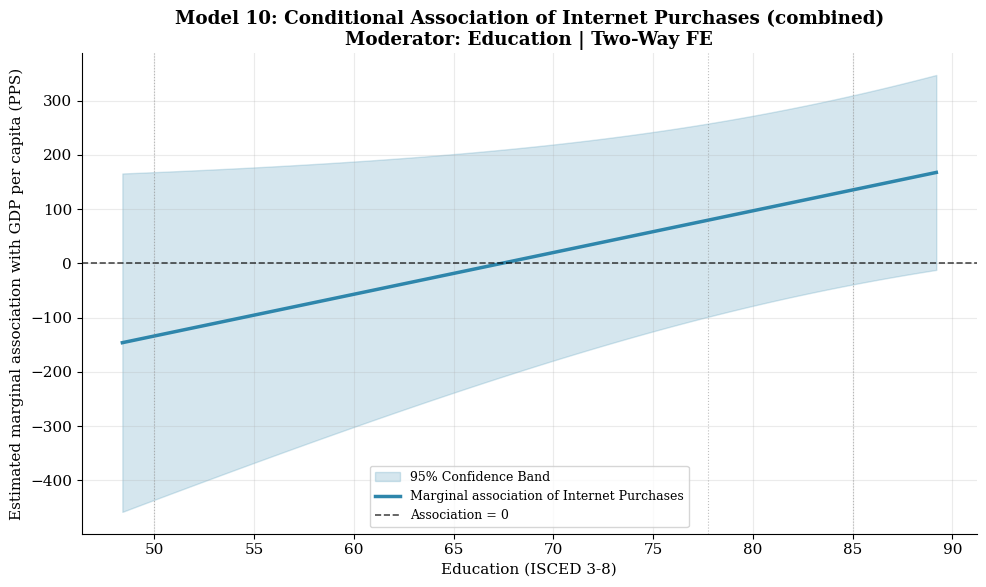

Marginaleffekt M10 positiv ab Bildungsniveau (ISCED 3-8) ≈ 67.4%


In [9]:
marginal_effect_plot(models["M5"], "Internet Use_c", "Use_x_Tert", "Internet Use", panel,
                     OUTPUT_DIR / "marginal_effect_model5.png",
                     "Model 5: Conditional Association of Internet Use\nModerator: Education | Two-Way FE")
marginal_effect_plot(models["M6"], "Internet Purchases_c", "Purch_x_Tert", "Internet Purchases", panel,
                     OUTPUT_DIR / "marginal_effect_model3a.png",
                     "Model 6: Conditional Association of Internet Purchases\nModerator: Education | Two-Way FE")
marginal_effect_plot(models["M10"], "Internet Purchases_c", "Purch_x_Tert", "Internet Purchases", panel,
                     OUTPUT_DIR / "marginal_effect_model10.png",
                     "Model 10: Conditional Association of Internet Purchases (combined)\nModerator: Education | Two-Way FE")

# Education level where the Model-10 marginal effect turns positive.
crossing = (panel["Tertiary_Education"].mean()
            - models["M10"].params["Internet Purchases_c"] / models["M10"].params["Purch_x_Tert"])
print(f"Marginaleffekt M10 positiv ab Bildungsniveau (ISCED 3-8) ≈ {crossing:.1f}%")

## 9. Tabelle 8 – Vollständige Ergebnisse Modell 10

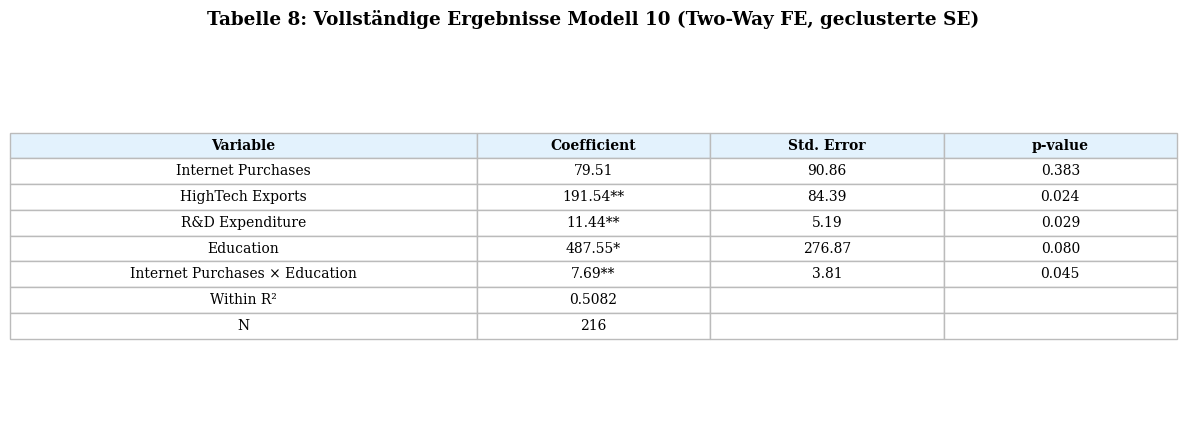

In [10]:
model10 = models["M10"]
labels = {"Internet Purchases_c": "Internet Purchases", "HighTech_Exports_c": "HighTech Exports",
          "R&D expenditure_c": "R&D Expenditure", "Tertiary_Education_c": "Education",
          "Purch_x_Tert": "Internet Purchases × Education"}
model10_rows = [[labels[v], f"{model10.params[v]:.2f}{stars(model10.pvalues[v])}",
                 f"{model10.std_errors[v]:.2f}", f"{model10.pvalues[v]:.3f}"]
                for v in ["Internet Purchases_c", "HighTech_Exports_c", "R&D expenditure_c",
                          "Tertiary_Education_c", "Purch_x_Tert"]]
model10_rows += [["Within R²", f"{model10.rsquared:.4f}", "", ""], ["N", str(int(model10.nobs)), "", ""]]
save_table(model10_rows, ["Variable", "Coefficient", "Std. Error", "p-value"],
           OUTPUT_DIR / "table8_model10_results.png",
           "Tabelle 8: Vollständige Ergebnisse Modell 10 (Two-Way FE, geclusterte SE)",
           col_widths=[0.40, 0.20, 0.20, 0.20], fontsize=10, figsize=(12, 4.5))

## 10. Verifikation gegen die bisherigen Ergebnisse

  [OK ] M10 Internet Purchases 79.5
  [OK ] M10 HighTech 191.5
  [OK ] M10 R&D 11.4
  [OK ] M10 Purch×Tert 7.7
  [OK ] M10 within R² 0.5082
ALLE WERTE IDENTISCH
